# Week 10: Clinical Care Prioritization and Ranking Engine

## 0. Imports y Configuración

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, roc_auc_score
)
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

label_encoding_maps = {
    'Gender': {0: 'Female', 1: 'Male'},
    'Blood Type': {0: 'A+', 1: 'A-', 2: 'AB+', 3: 'AB-', 4: 'B+', 5: 'B-', 6: 'O+', 7: 'O-'},
    'Medical Condition': {0: 'Arthritis', 1: 'Asthma', 2: 'Cancer', 3: 'Diabetes', 4: 'Hypertension', 5: 'Obesity'},
    'Insurance Provider': {0: 'Aetna', 1: 'Blue Cross', 2: 'Cigna', 3: 'Medicare', 4: 'UnitedHealthcare'},
    'Admission Type': {0: 'Elective', 1: 'Emergency', 2: 'Urgent'},
    'Medication': {0: 'Aspirin', 1: 'Ibuprofen', 2: 'Lipitor', 3: 'Paracetamol', 4: 'Penicillin'},
    'Test Results': {0: 'Normal', 1: 'Inconclusive', 2: 'Abnormal'},
    'Admission Day of Week': {0: 'Friday', 1: 'Monday', 2: 'Saturday', 3: 'Sunday', 4: 'Thursday', 5: 'Tuesday', 6: 'Wednesday'},
    'Admission Month': {0: 'April', 1: 'August', 2: 'December', 3: 'February', 4: 'January', 5: 'July', 6: 'June', 7: 'March', 8: 'May', 9: 'November', 10: 'October', 11: 'September'}
}

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


## 1. Carga y Alineación de Datos

In [63]:
# ── CARGA DE DATOS REALES ──
df = pd.read_csv('../data/interim/healtcare_processedv2.csv')
clusters_df = pd.read_csv('../data/processed/healthcare_pca_clusters.csv')

# Tomar solo las filas donde cluster no es NaN
clusters_df = clusters_df.dropna(subset=['cluster'])
clusters_df['Cluster_Biz'] = clusters_df['cluster'].astype(int)

# El dataset procesado también debe filtrarse a los mismos índices
df = df.loc[clusters_df.index].copy()
df['Cluster_Biz'] = clusters_df['Cluster_Biz'].values

# Feature de Semana 7
df['Cost_Per_Day'] = df['Billing Amount'] / df['Length of Stay']

print(f'Dataset final: {df.shape[0]:,} filas × {df.shape[1]} columnas')
print(f'\nCluster_Biz distribución:')
print(df['Cluster_Biz'].value_counts().sort_index())
print(f'\nDistribución de Test Results:')
print(df['Test Results'].value_counts(normalize=True).rename(label_encoding_maps['Test Results']).round(3))

Dataset final: 1,196 filas × 15 columnas

Cluster_Biz distribución:
Cluster_Biz
0    552
1     61
2     47
3    536
Name: count, dtype: int64

Distribución de Test Results:
Test Results
Normal          0.355
Abnormal        0.327
Inconclusive    0.318
Name: proportion, dtype: float64


## 2. Definition of the Candidate Pool and Train/Test Split

**Candidate Pool:** All patients with complete admission records (no null entries). In production, this corresponds to patients currently hospitalized or awaiting results.

**Split Strategy:** Stratified by Test Results to preserve class distribution.

**Ratio:** 80% train / 20% test — no temporary shuffle (limitation documented in section 6).

In [65]:
# Limpiar NaNs antes de todo
print(f'NaNs por columna:')
FEATURES = [
    'Age', 'Gender', 'Blood Type', 'Medical Condition',
    'Insurance Provider', 'Billing Amount', 'Admission Type',
    'Medication', 'Length of Stay', 'Admission Day of Week',
    'Admission Month', 'Admission Year', 'Cluster_Biz', 'Cost_Per_Day'
]
TARGET = 'Test Results'

# Limpiar NaNs antes de todo
print(f'NaNs por columna:')
print(df[FEATURES + [TARGET]].isna().sum())

df = df.dropna(subset=FEATURES + [TARGET])
print(f'\nDataset limpio: {df.shape[0]:,} filas')

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

df = df.dropna(subset=FEATURES + [TARGET])
print(f'\nDataset limpio: {df.shape[0]:,} filas')

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
# Removed: print(f'Distribución en test:')
# Removed: print(y_test.value_counts(normalize=True).rename({0:'Normal',1:'Inconclusive',2:'Abnormal'}).round(3)) # No longer needed here, as the previous cell prints this for the full dataset.

NaNs por columna:
NaNs por columna:
Age                      0
Gender                   0
Blood Type               0
Medical Condition        0
Insurance Provider       0
Billing Amount           0
Admission Type           0
Medication               0
Length of Stay           0
Admission Day of Week    0
Admission Month          0
Admission Year           0
Cluster_Biz              0
Cost_Per_Day             0
Test Results             0
dtype: int64

Dataset limpio: 1,196 filas
Train: 956 | Test: 240

Dataset limpio: 1,196 filas
Train: 956 | Test: 240


## 3. Baseline System

**Baseline Justification:** `DummyClassifier(strategy='most_frequent')` is used, which always predicts the most frequent class.

This is the most honest baseline: it represents a hospital system that does not personalize care and treats all patients the same.

Any useful model should significantly outperform it.

In [43]:
baseline = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
baseline.fit(X_train_sc, y_train)
y_pred_base = baseline.predict(X_test_sc)

acc_base = accuracy_score(y_test, y_pred_base)
f1_base  = f1_score(y_test, y_pred_base, average='macro', zero_division=0)

print('=== BASELINE: Most-Frequent Classifier ===')
print(f'Accuracy : {acc_base:.4f}')
print(f'F1 Macro : {f1_base:.4f}')
print('\nReporte:')
print(classification_report(y_test, y_pred_base,
      target_names=label_encoding_maps['Test Results'].values(), zero_division=0))

=== BASELINE: Most-Frequent Classifier ===
Accuracy : 0.3542
F1 Macro : 0.1744

Reporte:
              precision    recall  f1-score   support

      Normal       0.35      1.00      0.52        85
Inconclusive       0.00      0.00      0.00        76
    Abnormal       0.00      0.00      0.00        79

    accuracy                           0.35       240
   macro avg       0.12      0.33      0.17       240
weighted avg       0.13      0.35      0.19       240



## 4. Advanced Models

Two more robust models are evaluated:

| Model | Justification |

**Logistic Regression** | Interpretable linear model; serves as a step between baseline and RF |

**Random Forest** | Handles non-linearities, coded categorical variables, and allows for feature importance |

In [72]:
# ── Logistic Regression ──
lr = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr  = f1_score(y_test, y_pred_lr, average='macro')

print('=== Logistic Regression Balanceado ===')
print(f'Accuracy : {acc_lr:.4f}  |  F1 Macro: {f1_lr:.4f}')
print(classification_report(y_test, y_pred_lr, target_names=label_encoding_maps['Test Results'].values()))

=== Logistic Regression Balanceado ===
Accuracy : 0.3458  |  F1 Macro: 0.3446
              precision    recall  f1-score   support

      Normal       0.37      0.35      0.36        85
Inconclusive       0.32      0.30      0.31        76
    Abnormal       0.35      0.38      0.37        79

    accuracy                           0.35       240
   macro avg       0.34      0.35      0.34       240
weighted avg       0.35      0.35      0.35       240



In [73]:
# ── Random Forest ──
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
)
rf.fit(X_train_sc, y_train)
y_pred_rf = rf.predict(X_test_sc)
y_prob_rf  = rf.predict_proba(X_test_sc)

acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='macro')

print('=== Random Forest ===')
print(f'Accuracy : {acc_rf:.4f}  |  F1 Macro: {f1_rf:.4f}')
print(classification_report(y_test, y_pred_rf,
      target_names=label_encoding_maps['Test Results'].values()))

=== Random Forest ===
Accuracy : 0.3375  |  F1 Macro: 0.3359
              precision    recall  f1-score   support

      Normal       0.33      0.39      0.36        85
Inconclusive       0.35      0.33      0.34        76
    Abnormal       0.33      0.29      0.31        79

    accuracy                           0.34       240
   macro avg       0.34      0.34      0.34       240
weighted avg       0.34      0.34      0.34       240



## 5. Offline Evaluation Report

### Model Comparison Table

In [74]:
results = pd.DataFrame({
    'Modelo':    ['Baseline (Most Frequent)', 'Logistic Regression', 'Random Forest', 'Gradient Boosting'],
    'Accuracy':  [acc_base, acc_lr, acc_rf, acc_gb],
    'F1 Macro':  [f1_base, f1_lr, f1_rf, f1_gb],
})
print(results.to_string(index=False))

                  Modelo  Accuracy  F1 Macro
Baseline (Most Frequent)  0.354167  0.174359
     Logistic Regression  0.345833  0.344620
           Random Forest  0.337500  0.335852
       Gradient Boosting  0.291667  0.284606


                  Modelo  Accuracy  F1 Macro
Baseline (Most Frequent)  0.354167  0.174359
     Logistic Regression  0.345833  0.344620
           Random Forest  0.337500  0.335852


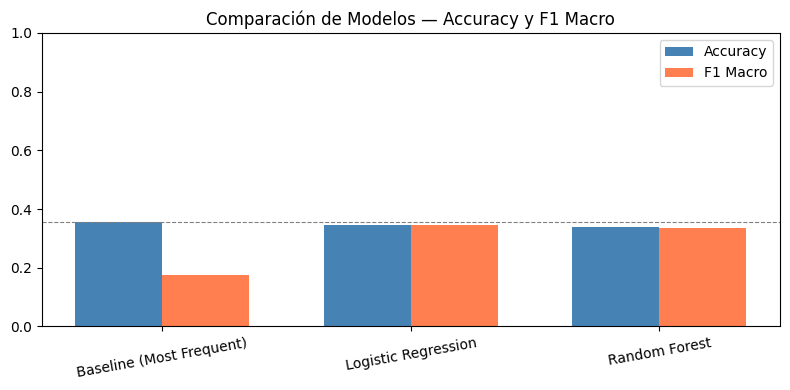

Gráfico guardado: model_comparison.png


In [75]:
results = pd.DataFrame({
    'Modelo':    ['Baseline (Most Frequent)', 'Logistic Regression', 'Random Forest'],
    'Accuracy':  [acc_base, acc_lr, acc_rf],
    'F1 Macro':  [f1_base, f1_lr, f1_rf],
})
print(results.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
x = np.arange(3)
width = 0.35
ax.bar(x - width/2, results['Accuracy'], width, label='Accuracy', color='steelblue')
ax.bar(x + width/2, results['F1 Macro'],  width, label='F1 Macro',  color='coral')
ax.set_xticks(x)
ax.set_xticklabels(results['Modelo'], rotation=10)
ax.set_ylim(0, 1)
ax.set_title('Comparación de Modelos — Accuracy y F1 Macro')
ax.legend()
ax.axhline(acc_base, color='gray', linestyle='--', linewidth=0.8, label='Baseline')
plt.tight_layout()
#plt.savefig('model_comparison.png', dpi=150)
plt.show()
print('Gráfico guardado: model_comparison.png')

Logistic Regression — CV F1 Macro: 0.3051 ± 0.0527
Random Forest       — CV F1 Macro: 0.3311 ± 0.0412


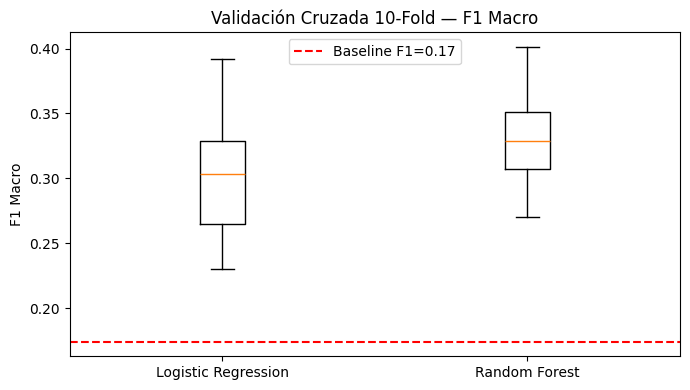

In [77]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

cv_scores_lr = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
cv_scores_rf = cross_val_score(rf, X_train_sc, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)

print(f'Logistic Regression — CV F1 Macro: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')
print(f'Random Forest       — CV F1 Macro: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')

# Visualización
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([cv_scores_lr, cv_scores_rf], labels=['Logistic Regression', 'Random Forest'])
ax.axhline(f1_base, color='red', linestyle='--', label=f'Baseline F1={f1_base:.2f}')
ax.set_ylabel('F1 Macro')
ax.set_title('Validación Cruzada 10-Fold — F1 Macro')
ax.legend()
plt.tight_layout()
#plt.savefig('cross_validation.png', dpi=150)
plt.show()

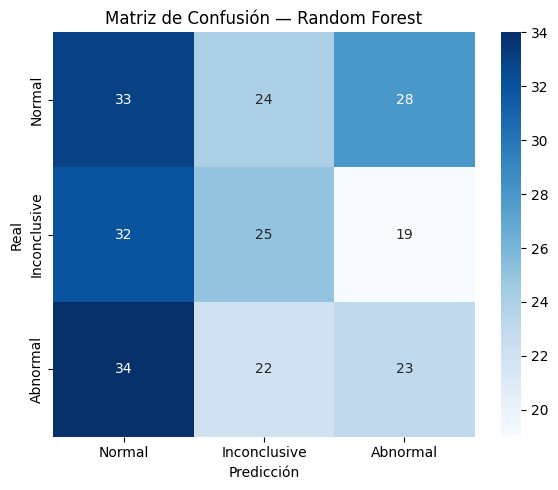

In [78]:
# Matriz de confusión — Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoding_maps['Test Results'].values(),
            yticklabels=label_encoding_maps['Test Results'].values(), ax=ax)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de Confusión — Random Forest')
plt.tight_layout()
#plt.savefig('confusion_matrix_rf.png', dpi=150)
plt.show()

### Primary Metric: F1 Macro

**F1 Macro** was chosen as the primary metric because:
1. All three classes have clinically relevant weight — *Abnormal* is critical, but *Inconclusive* also requires follow-up.
2. F1 Macro treats all classes equally, preventing the model from ignoring minorities.
3. Accuracy alone is misleading in unbalanced datasets.

**What the metric does not capture:** It does not differentiately penalize the error of classifying *Abnormal* as *Normal* (critical false negative). In production, an asymmetric cost function would be recommended.

## 6. Importance of Features

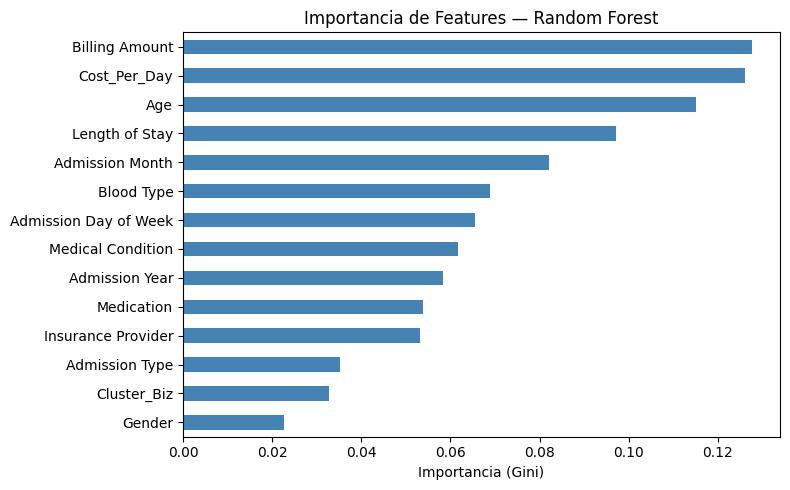

Top 5 features:
Billing Amount     0.127557
Cost_Per_Day       0.126066
Age                0.115126
Length of Stay     0.097201
Admission Month    0.082118
dtype: float64


In [79]:
feat_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 5))
feat_imp.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Importancia de Features — Random Forest')
ax.set_xlabel('Importancia (Gini)')
plt.tight_layout()
#plt.savefig('feature_importance.png', dpi=150)
plt.show()

print('Top 5 features:')
print(feat_imp.head())

## 7. Error Analysis
Cases where the model fails to understand the profile of misclassified patients are examined.

In [80]:
error_mask = y_pred_rf != y_test.values
X_errors   = X_test[error_mask].copy()
X_errors['y_real'] = y_test.values[error_mask]
X_errors['y_pred'] = y_pred_rf[error_mask]

print(f'Total errores: {error_mask.sum():,} / {len(y_test):,} ({error_mask.mean()*100:.1f}%)')
print()

# Tipo de error más común
error_pairs = pd.crosstab(
    X_errors['y_real'].map(label_encoding_maps['Test Results']),
    X_errors['y_pred'].map(label_encoding_maps['Test Results']),
    rownames=['Real'], colnames=['Predicho']
)
print('Patrones de error (Real → Predicho):')
print(error_pairs)
print('Predicciones únicas del modelo:')
print(pd.Series(y_pred_lr).value_counts().rename(label_encoding_maps['Test Results']))
print()

# Perfil de errores críticos: Abnormal clasificado como Normal
critical_errors = X_errors[(X_errors['y_real']==2) & (X_errors['y_pred']==0)]
print(f'Errores críticos (Abnormal → Normal): {len(critical_errors):,}')
if len(critical_errors) > 0:
    print('Perfil promedio de estos pacientes:')
    print(critical_errors[['Age','Medical Condition','Admission Type','Cost_Per_Day']].describe().loc[['mean','min','max']].round(2))

Total errores: 159 / 240 (66.2%)

Patrones de error (Real → Predicho):
Predicho      Abnormal  Inconclusive  Normal
Real                                        
Abnormal             0            22      34
Inconclusive        19             0      32
Normal              28            24       0
Predicciones únicas del modelo:
Abnormal        85
Normal          82
Inconclusive    73
Name: count, dtype: int64

Errores críticos (Abnormal → Normal): 34
Perfil promedio de estos pacientes:
        Age  Medical Condition  Admission Type  Cost_Per_Day
mean  54.59               2.53            0.97       2738.27
min   23.00               0.00            0.00        115.56
max   84.00               5.00            2.00      17679.03


In [82]:
# Ejemplos concretos de casos correctos e incorrectos
X_test_display = X_test.copy()
X_test_display['y_real'] = y_test.values
X_test_display['y_pred'] = y_pred_rf
X_test_display['correcto'] = (X_test_display['y_real'] == X_test_display['y_pred'])

X_test_display['y_real_label'] = X_test_display['y_real'].map(label_encoding_maps['Test Results'])
X_test_display['y_pred_label'] = X_test_display['y_pred'].map(label_encoding_maps['Test Results'])
X_test_display['Medical Condition_label'] = X_test_display['Medical Condition'].map(label_encoding_maps['Medical Condition'])
X_test_display['Admission Type_label'] = X_test_display['Admission Type'].map(label_encoding_maps['Admission Type'])

print('=== 3 Casos BIEN clasificados ===')
print(X_test_display[X_test_display['correcto']].head(3)[['Age','Medical Condition_label','Admission Type_label','y_real_label','y_pred_label']].to_string())
print()
print('=== 3 Casos MAL clasificados ===')
print(X_test_display[~X_test_display['correcto']].head(3)[['Age','Medical Condition_label','Admission Type_label','y_real_label','y_pred_label']].to_string())

=== 3 Casos BIEN clasificados ===
     Age Medical Condition_label Admission Type_label  y_real_label  y_pred_label
877   52               Arthritis            Emergency        Normal        Normal
153   67               Arthritis             Elective        Normal        Normal
140   42                Diabetes               Urgent  Inconclusive  Inconclusive

=== 3 Casos MAL clasificados ===
     Age Medical Condition_label Admission Type_label y_real_label  y_pred_label
34    30                Diabetes            Emergency     Abnormal  Inconclusive
967   83                  Asthma               Urgent       Normal  Inconclusive
162   65                  Asthma            Emergency       Normal      Abnormal


## 8. Predictive Ranking Engine — Aplicación del Modelo

El modelo produce una **probabilidad de resultado Abnormal** para cada paciente.  
Ordenando por esta probabilidad de mayor a menor, obtenemos la **cola de priorización clínica**.

In [83]:
# ── RANKING DE PRIORIDAD CLÍNICA ──
y_prob_rf = rf.predict_proba(X_test_sc)  # ← cambio: RF en lugar de LR

ranking_df = X_test.copy()
ranking_df['prob_normal']       = y_prob_rf[:, 0].round(3)
ranking_df['prob_inconclusive'] = y_prob_rf[:, 1].round(3)
ranking_df['prob_abnormal']     = y_prob_rf[:, 2].round(3)  # ← cambio
ranking_df['predicted_class']   = [label_encoding_maps['Test Results'][x] for x in y_pred_rf]  # ← cambio
ranking_df['real_class']        = [label_encoding_maps['Test Results'][x] for x in y_test.values]
ranking_df['Medical Condition_label'] = ranking_df['Medical Condition'].map(label_encoding_maps['Medical Condition'])
ranking_df['Admission Type_label'] = ranking_df['Admission Type'].map(label_encoding_maps['Admission Type'])
ranking_df['priority_rank']     = ranking_df['prob_abnormal'].rank(ascending=False).astype(int)
ranking_df = ranking_df.sort_values('priority_rank')

print('Top 10 pacientes con mayor riesgo de resultado Abnormal:')
print(ranking_df[['Age', 'Medical Condition_label', 'Admission Type_label',
                   'prob_abnormal', 'predicted_class', 'real_class',
                   'priority_rank']].head(10).to_string())

# Guardar ranking completo
ranking_df.to_csv('../data/processed/ranking_prioridad_clinica.csv', index=False)
print('\nRanking guardado: ranking_prioridad_clinica.csv')

Top 10 pacientes con mayor riesgo de resultado Abnormal:
      Age Medical Condition_label Admission Type_label  prob_abnormal predicted_class    real_class  priority_rank
1134   70            Hypertension             Elective          0.542        Abnormal        Normal              1
1155   55               Arthritis             Elective          0.523        Abnormal      Abnormal              2
143    54                Diabetes             Elective          0.519        Abnormal      Abnormal              3
553    34                  Asthma               Urgent          0.500        Abnormal  Inconclusive              4
199    20                 Obesity            Emergency          0.497        Abnormal        Normal              5
740    28                  Cancer               Urgent          0.486        Abnormal        Normal              6
154    66               Arthritis             Elective          0.478        Abnormal        Normal              7
1070   56              

In [84]:
# Precisión del ranking en top-N
for n in [10, 20, 50]:
    top_n = ranking_df.head(n)
    precision_n = (top_n['real_class'] == 'Abnormal').mean()
    print(f'Precisión en Top-{n}: {precision_n:.2f} ({int(precision_n*n)}/{n} realmente Abnormal)')

# Comparar vs aleatorio
baseline_precision = (y_test == 2).mean()
print(f'\nPrecisión aleatoria esperada: {baseline_precision:.2f}')

Precisión en Top-10: 0.20 (2/10 realmente Abnormal)
Precisión en Top-20: 0.40 (8/20 realmente Abnormal)
Precisión en Top-50: 0.32 (16/50 realmente Abnormal)

Precisión aleatoria esperada: 0.33


## 9. Validación Cruzada

In [85]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

cv_scores_rf = cross_val_score(rf, X_train_sc, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
cv_scores_lr = cross_val_score(lr, X_train_sc, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)

print(f'Random Forest  — CV F1 Macro: {cv_scores_rf.mean():.4f} ± {cv_scores_rf.std():.4f}')
print(f'Logistic Reg.  — CV F1 Macro: {cv_scores_lr.mean():.4f} ± {cv_scores_lr.std():.4f}')
print()
print('Interpretación: La desviación estándar indica estabilidad del modelo bajo distintos folds.')

Random Forest  — CV F1 Macro: 0.3311 ± 0.0412
Logistic Reg.  — CV F1 Macro: 0.3051 ± 0.0527

Interpretación: La desviación estándar indica estabilidad del modelo bajo distintos folds.
